<a href="https://colab.research.google.com/github/dwiratnaanggraeni/Visualisasi-Data-dan-Informasi-/blob/main/TUBES_VDI_kelompok%2010%20RB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelompok 10 visualisasi Data dan Informasi RB

Anggota:
1. Dwi Ratna Anggareni (122450008)
2. Cyntia Kristina Sidauruk (122450023)
3. Oktavia Nurwenda Puspita (122450041)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/dataset_TSMC2014_NYC (2).csv")
df1= pd.read_csv("/content/dataset_TSMC2014_TKY.csv")

## Preprocessing dataset

Data NYC

In [ ]:
df.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012


In [ ]:
df.isnull().sum()

,0
userId,0
venueId,0
venueCategoryId,0
venueCategory,0
latitude,0
longitude,0
timezoneOffset,0
utcTimestamp,0


In [ ]:
df['venueCategory'].unique()

array(['Arts & Crafts Store', 'Bridge', 'Home (private)',
       'Medical Center', 'Food Truck', 'Food & Drink Shop', 'Coffee Shop',
       'Bus Station', 'Bank', 'Gastropub', 'Electronics Store',
       'Mobile Phone Shop', 'Café', 'Automotive Shop', 'Restaurant',
       'American Restaurant', 'Government Building', 'Airport', 'Ferry',
       'Office', 'Other Great Outdoors', 'Building', 'Mexican Restaurant',
       'Music Venue', 'Subway', 'Student Center', 'Park', 'Road',
       'Burger Joint', 'Sporting Goods Shop', 'Pizza Place',
       'Jewelry Store', 'Sandwich Place', 'Clothing Store',
       'Neighborhood', 'Ice Cream Shop', 'Soup Place',
       'College Academic Building', 'Department Store', 'Playground',
       'Tattoo Parlor', 'Mall', 'Deli / Bodega', 'University', 'Diner',
       'Music Store', 'Light Rail', 'Salon / Barbershop',
       'General College & University', 'Animal Shelter',
       'Laundry Service', 'Residential Building (Apartment / Condo)',
       'Drugstore

Data TKY

In [ ]:
df1.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540,Tue Apr 03 18:17:18 +0000 2012
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540,Tue Apr 03 18:22:04 +0000 2012
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540,Tue Apr 03 19:12:07 +0000 2012
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540,Tue Apr 03 19:12:13 +0000 2012
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734046,540,Tue Apr 03 19:18:23 +0000 2012


In [ ]:
df1.isnull().sum()

,0
userId,0
venueId,0
venueCategoryId,0
venueCategory,0
latitude,0
longitude,0
timezoneOffset,0
utcTimestamp,0


In [ ]:
df1['venueCategory'].unique()

array(['Cosmetics Shop', 'Ramen /  Noodle House', 'Convenience Store',
       'Food & Drink Shop', 'Housing Development',
       'Furniture / Home Store', 'Train Station', 'Other Great Outdoors',
       'Airport', 'Bus Station', 'Bridge', 'Road', 'Subway', 'Park',
       'Post Office', 'Light Rail', 'Shrine', 'Fast Food Restaurant',
       'University', 'Government Building', 'Restaurant', 'Café',
       'Gym / Fitness Center', 'Candy Store', 'Mall', 'Home (private)',
       'Other Nightlife', 'Coffee Shop', 'Office', 'Japanese Restaurant',
       'Fried Chicken Joint', 'Bar', 'Toy / Game Store', 'Building',
       'Scenic Lookout', 'Flower Shop', 'Miscellaneous Shop',
       'Video Store', 'College Academic Building', 'Student Center',
       'Internet Cafe', 'Medical Center', 'Event Space', 'Smoke Shop',
       'History Museum', 'Movie Theater', 'School', 'Parking', 'Bakery',
       'Pool', 'General College & University', 'Temple', 'Burger Joint',
       'Historic Site', 'Electronics

### Spliting data

In [ ]:
# split waktu
for dataset in [df, df1]:
    dataset['utcTimestamp'] = pd.to_datetime(dataset['utcTimestamp'])
    dataset['dayOfWeek'] = dataset['utcTimestamp'].dt.day_name()
    dataset['isWeekend'] = dataset['dayOfWeek'].isin(['Saturday', 'Sunday'])
    dataset['hour'] = dataset['utcTimestamp'].dt.hour

# Menampilkan hasil dari perubahan waktu
print("Hasil perubahan waktu pada df:")
print(df[['utcTimestamp', 'dayOfWeek', 'isWeekend', 'hour']].head())

print("\nHasil perubahan waktu pada df1:")
print(df1[['utcTimestamp', 'dayOfWeek', 'isWeekend', 'hour']].head())


Hasil perubahan waktu pada df:
               utcTimestamp dayOfWeek  isWeekend  hour
0 2012-04-03 18:00:09+00:00   Tuesday      False    18
1 2012-04-03 18:00:25+00:00   Tuesday      False    18
2 2012-04-03 18:02:24+00:00   Tuesday      False    18
3 2012-04-03 18:02:41+00:00   Tuesday      False    18
4 2012-04-03 18:03:00+00:00   Tuesday      False    18

Hasil perubahan waktu pada df1:
               utcTimestamp dayOfWeek  isWeekend  hour
0 2012-04-03 18:17:18+00:00   Tuesday      False    18
1 2012-04-03 18:22:04+00:00   Tuesday      False    18
2 2012-04-03 19:12:07+00:00   Tuesday      False    19
3 2012-04-03 19:12:13+00:00   Tuesday      False    19
4 2012-04-03 19:18:23+00:00   Tuesday      False    19


In [ ]:
# Mapping kategori
mapping = {
    "Food & Drink": ["Restaurant", "Coffee Shop", "Café", "Burger Joint", "Pizza Place", "Sandwich Place", "BBQ Joint", "Fast Food Restaurant", "Deli / Bodega", "Diner", "Soup Place", "Ice Cream Shop", "Bakery", "Dessert Shop", "Snack Place", "Wings Joint", "Sushi Restaurant", "Seafood Restaurant", "Chinese Restaurant", "French Restaurant", "Italian Restaurant", "Mexican Restaurant", "Asian Restaurant", "Japanese Restaurant", "Thai Restaurant", "Korean Restaurant", "Indian Restaurant", "Mediterranean Restaurant", "Greek Restaurant", "Vietnamese Restaurant", "Cuban Restaurant", "Spanish Restaurant", "Latin American Restaurant", "Brazilian Restaurant", "Turkish Restaurant", "Middle Eastern Restaurant", "African Restaurant", "Ethiopian Restaurant", "Argentinian Restaurant", "Cajun / Creole Restaurant", "South American Restaurant", "Swiss Restaurant", "Portuguese Restaurant", "Peruvian Restaurant", "Malaysian Restaurant", "Australian Restaurant", "Filipino Restaurant", "Dim Sum Restaurant", "Ramen /  Noodle House", "Falafel Restaurant", "Taco Place", "Bagel Shop", "Hot Dog Joint", "Arepa Restaurant", "Mac & Cheese Joint", "Molecular Gastronomy Restaurant", "Gluten-free Restaurant", "Breakfast Spot", "Tea Room", "Food Truck"],
    "Shopping": ["Clothing Store", "Department Store", "Jewelry Store", "Cosmetics Shop", "Electronics Store", "Mobile Phone Shop", "Miscellaneous Shop", "Bookstore", "Toy / Game Store", "Video Game Store", "Hobby Shop", "Camera Store", "Flower Shop", "Furniture / Home Store", "Sporting Goods Shop", "Candy Store", "Gift Shop", "Arts & Crafts Store", "Antique Shop", "Thrift / Vintage Store", "Board Shop", "Music Store", "Bike Shop", "Motorcycle Shop", "Market", "Paper / Office Supplies Store", "Newsstand", "Mall"],
    "Entertainment": ["Movie Theater", "Concert Hall", "Theater", "Comedy Club", "Art Gallery", "Art Museum", "History Museum", "Science Museum", "Sculpture Garden", "Zoo", "Aquarium", "Planetarium", "Public Art", "Music Venue", "Gaming Cafe", "Arcade", "Casino", "Fair", "Stadium", "College Stadium", "Racetrack"],
    "Travel & Transport": ["Airport", "Train Station", "Bus Station", "Subway", "Light Rail", "Ferry", "Taxi", "Rental Car Location", "Travel Lounge", "General Travel", "Parking", "Rest Area", "Harbor / Marina"],
    "Nightlife": ["Bar", "Gastropub", "Beer Garden", "Nightlife Spot", "Other Nightlife", "Pool Hall", "Brewery", "Distillery"],
    "Health & Wellness": ["Gym / Fitness Center", "Spa / Massage", "Salon / Barbershop", "Nail Salon", "Tanning Salon"],
    "Education": ["University", "General College & University", "College Academic Building", "College Theater", "Student Center", "Community College", "Law School", "Medical School", "Trade School", "High School", "Middle School", "Elementary School", "Nursery School", "Music School"],
    "Outdoors": ["Park", "Playground", "Beach", "Garden", "Other Great Outdoors", "River", "Scenic Lookout", "Campground", "Housing Development", "Ski Area", "Shrine", "Temple", "Church", "Mosque", "Synagogue", "Cemetery", "Castle", "City"],
    "Professional": ["Office", "Government Building", "Post Office", "Bank", "Embassy / Consulate", "Financial or Legal Service", "Storage Facility", "Military Base", "Recycling Facility", "Factory", "Design Studio", "Photography Lab", "Moving Target"],
    "Home & Residential": ["Home (private)", "Residential Building (Apartment / Condo)", "Sorority House", "Fraternity House"],
    "Transportation Services": ["Gas Station / Garage", "Car Wash", "Car Dealership"],
    "Specialty": ["Tattoo Parlor", "Animal Shelter", "Pet Store", "Pet Service", "Bike Rental / Bike Share", "Flower Shop", "Bridal Shop", "Garden Center", "Professional & Other Places"]
}

# Membalikkan mapping untuk mempermudah pencocokan
inverse_mapping = {item: key for key, values in mapping.items() for item in values}

# Menambahkan broadCategory
for dataset in [df, df1]:
    dataset['broadCategory'] = dataset['venueCategory'].map(inverse_mapping)

# Menampilkan hasil dari mapping kategori
print("\nHasil mapping kategori pada df:")
print(df[['venueCategory', 'broadCategory']].head())

print("\nHasil mapping kategori pada df1:")
print(df1[['venueCategory', 'broadCategory']].head())



Hasil mapping kategori pada df:
         venueCategory       broadCategory
0  Arts & Crafts Store            Shopping
1               Bridge                 NaN
2       Home (private)  Home & Residential
3       Medical Center                 NaN
4           Food Truck        Food & Drink

Hasil mapping kategori pada df1:
           venueCategory broadCategory
0         Cosmetics Shop      Shopping
1  Ramen /  Noodle House  Food & Drink
2      Convenience Store           NaN
3      Food & Drink Shop           NaN
4    Housing Development      Outdoors


## Pertanyaan 1

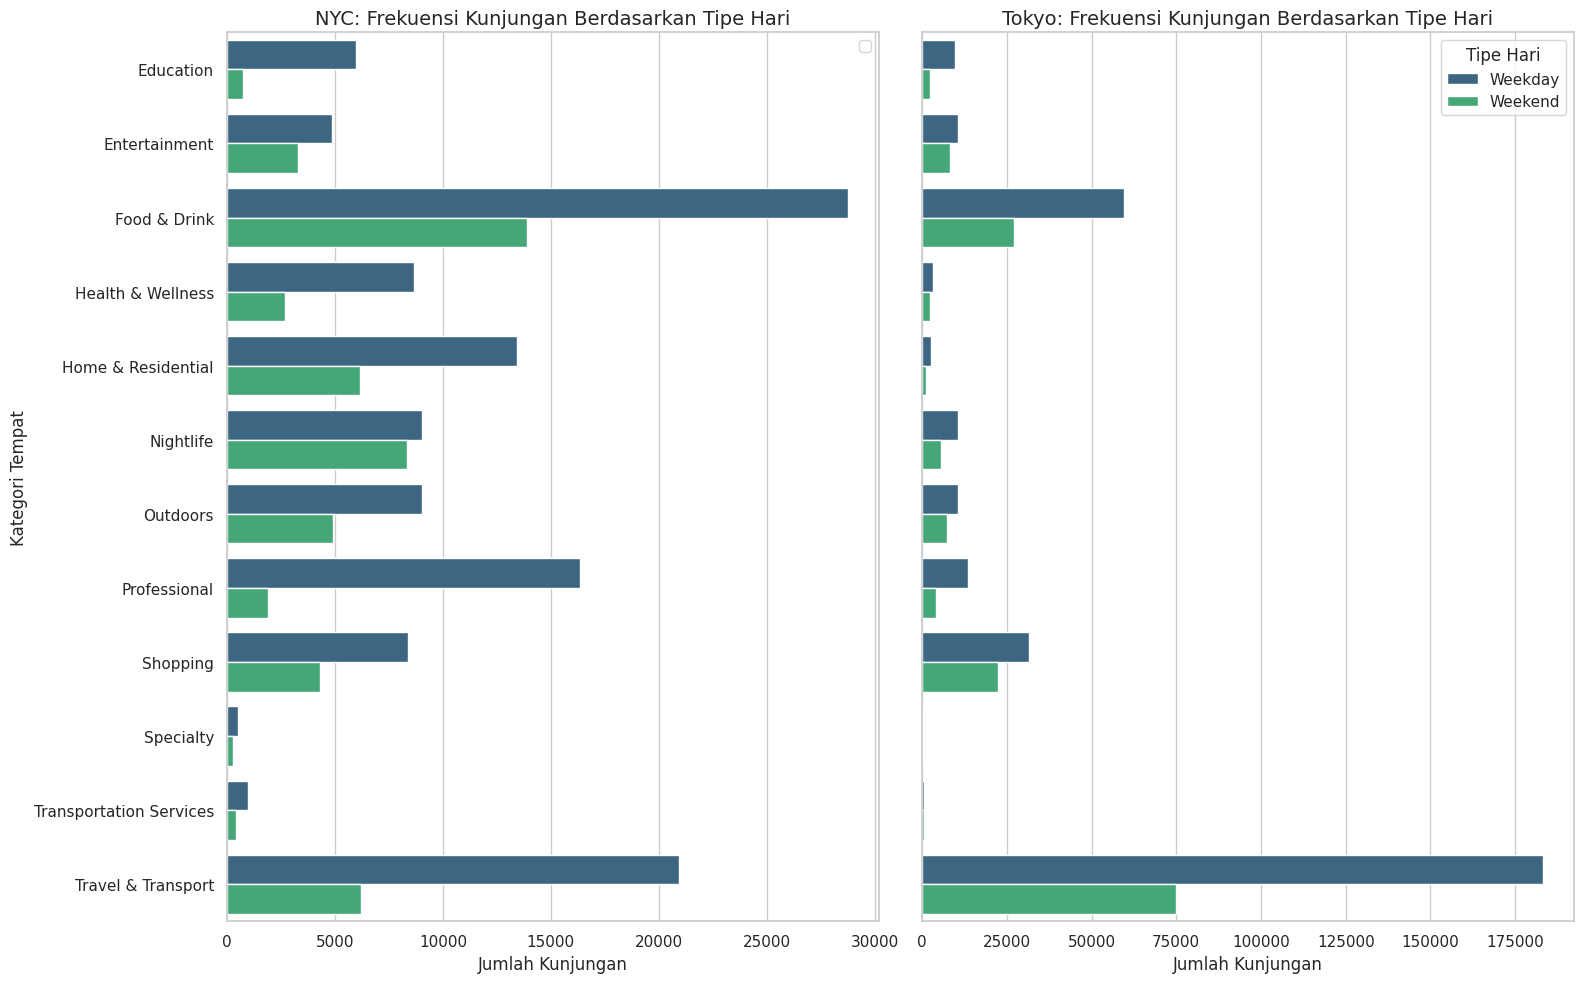

In [ ]:
# Mengelompokkan data berdasarkan tipe hari dan kategori tempat
df['dayType'] = df['isWeekend'].apply(lambda x: 'Weekend' if x else 'Weekday')
grouped_nyc = df.groupby(['dayType', 'broadCategory']).size().reset_index(name='count')

df1['dayType'] = df1['isWeekend'].apply(lambda x: 'Weekend' if x else 'Weekday')
grouped_tokyo = df1.groupby(['dayType', 'broadCategory']).size().reset_index(name='count')

# Membuat subplots untuk kedua visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

# Plot untuk NYC
sns.barplot(
    data=grouped_nyc,
    y='broadCategory',
    x='count',
    hue='dayType',
    palette='viridis',
    orient='h',
    ax=axes[0]
)
axes[0].set_title('NYC: Frekuensi Kunjungan Berdasarkan Tipe Hari', fontsize=14)
axes[0].set_xlabel('Jumlah Kunjungan', fontsize=12)
axes[0].set_ylabel('Kategori Tempat', fontsize=12)
axes[0].legend('')

# Plot untuk Tokyo
sns.barplot(
    data=grouped_tokyo,
    y='broadCategory',
    x='count',
    hue='dayType',
    palette='viridis',
    orient='h',
    ax=axes[1]
)
axes[1].set_title('Tokyo: Frekuensi Kunjungan Berdasarkan Tipe Hari', fontsize=14)
axes[1].set_xlabel('Jumlah Kunjungan', fontsize=12)
axes[1].set_ylabel('')
axes[1].legend(title='Tipe Hari', loc='upper right')

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()


## Pertanyaan 2

Waktu puncak kunjungan di NYC: Jam 23
Waktu puncak kunjungan di Tokyo: Jam 9


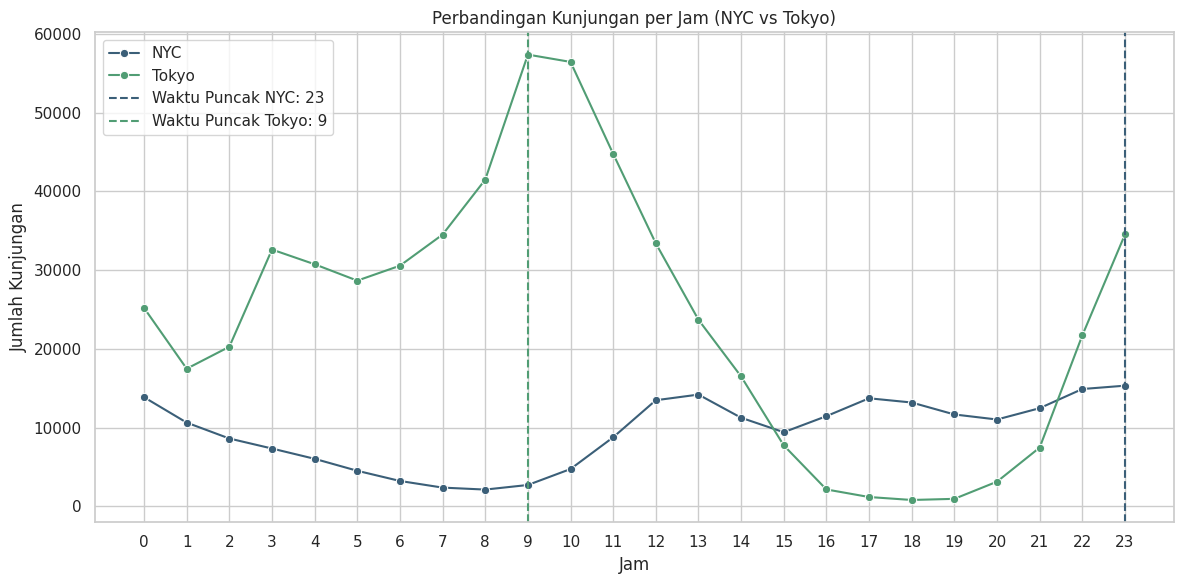

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import viridis

# Menghitung jumlah kunjungan per jam untuk masing-masing kota
peak_hours_nyc = df['hour'].value_counts().sort_index()
peak_hours_tky = df1['hour'].value_counts().sort_index()

# Menentukan waktu puncak kunjungan untuk masing-masing kota
nyc_peak_hour = peak_hours_nyc.idxmax()
tky_peak_hour = peak_hours_tky.idxmax()

print(f"Waktu puncak kunjungan di NYC: Jam {nyc_peak_hour}")
print(f"Waktu puncak kunjungan di Tokyo: Jam {tky_peak_hour}")


# Membuat plot gabungan
plt.figure(figsize=(12, 6))

# Plot untuk NYC
sns.lineplot(x=peak_hours_nyc.index, y=peak_hours_nyc.values, marker="o", label="NYC", color='#3B5F78')

# Plot untuk Tokyo
sns.lineplot(x=peak_hours_tky.index, y=peak_hours_tky.values, marker="o", label="Tokyo", color='#519D74')

# Menambahkan garis vertikal untuk waktu puncak
plt.axvline(nyc_peak_hour, color='#3B5F78', linestyle='--', label=f'Waktu Puncak NYC: {nyc_peak_hour}')
plt.axvline(tky_peak_hour, color='#519D74', linestyle='--', label=f'Waktu Puncak Tokyo: {tky_peak_hour}')

# Menambahkan judul dan label
plt.title("Perbandingan Kunjungan per Jam (NYC vs Tokyo)")
plt.xlabel("Jam")
plt.ylabel("Jumlah Kunjungan")
plt.xticks(range(0, 24))
plt.legend()

# Menampilkan plot
plt.tight_layout()
plt.show()


## Pertanyaan 3

<ipython-input-22-0b9fba72889a>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-22-0b9fba72889a>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


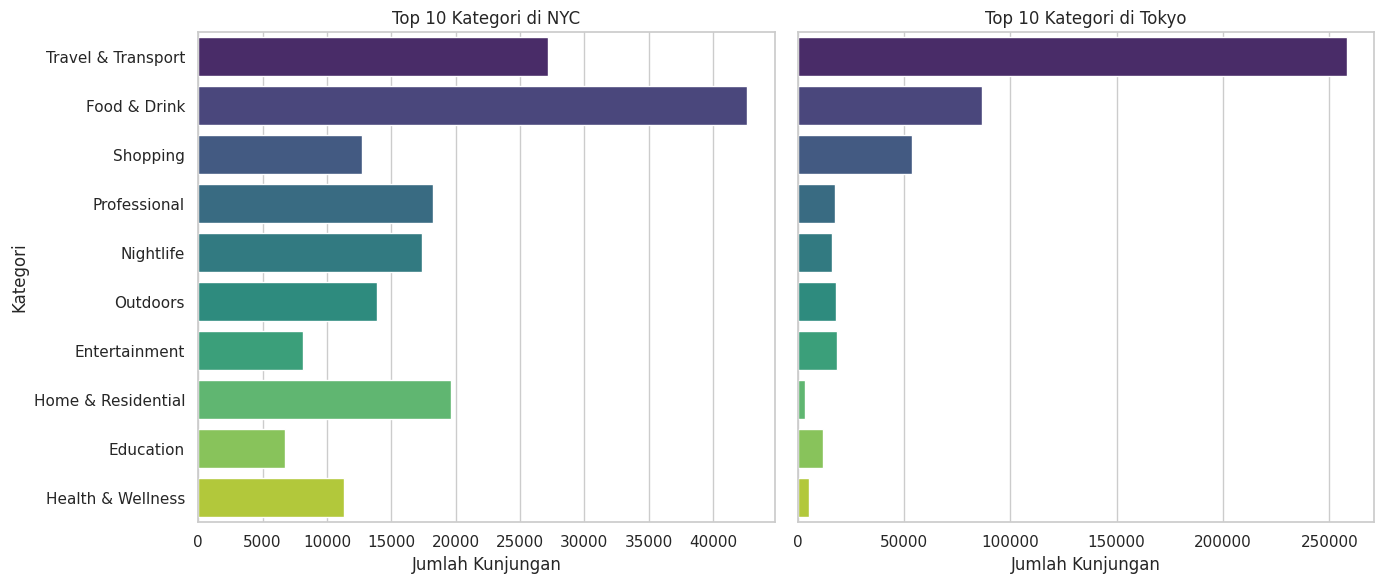

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung kategori tempat paling sering dikunjungi untuk NYC
top_categories_nyc = df['broadCategory'].value_counts()

# Menghitung kategori tempat paling sering dikunjungi untuk Tokyo
top_categories_tky = df1['broadCategory'].value_counts()

# Gabungkan kategori dari kedua kota dan urutkan berdasarkan jumlah total kunjungan
combined_categories = pd.concat([top_categories_nyc, top_categories_tky], axis=1, keys=['NYC', 'Tokyo']).fillna(0)
combined_categories = combined_categories.sum(axis=1).sort_values(ascending=False)

# Ambil 10 kategori teratas berdasarkan jumlah kunjungan
top_categories_combined = combined_categories.head(10)

# Membuat palet warna yang sesuai dengan jumlah kategori
palette = sns.color_palette("viridis", len(top_categories_combined))

# Membuat visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot untuk NYC
sns.barplot(
    x=top_categories_nyc[top_categories_combined.index].values,
    y=top_categories_combined.index,
    ax=axes[0],
    palette=palette
)
axes[0].set_title("Top 10 Kategori di NYC")
axes[0].set_xlabel("Jumlah Kunjungan")
axes[0].set_ylabel("Kategori")

# Plot untuk Tokyo
sns.barplot(
    x=top_categories_tky[top_categories_combined.index].values,
    y=top_categories_combined.index,
    ax=axes[1],
    palette=palette
)
axes[1].set_title("Top 10 Kategori di Tokyo")
axes[1].set_xlabel("Jumlah Kunjungan")

# Menampilkan grafik
plt.tight_layout()
plt.show()
